# ISAB Mathematical Correctness & Mask Verification

This notebook visualizes the correctness of the ISAB (Induced Set Attention Block) implementation:

1. **Attention direction**: Q/KV roles in CrossAttention
2. **Two-pass structure**: Inducing←Set then Set←Inducing
3. **Mask materialization**: Cell-by-cell mask correctness for both passes
4. **Perturbation isolation**: Heatmaps showing padding doesn't affect valid positions
5. **Low-rank bottleneck**: Singular value spectrum of effective attention
6. **Gradient flow**: Where gradients reach (and don't) through masks
7. **Permutation equivariance**: Visual proof of set invariance

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns

from networks.set_transformer_torch import (
    ISAB, MAB, CrossAttention,
    create_kv_padding_block_mask, create_q_padding_block_mask,
)
from models.model import PeakSetSIGReg

sns.set_theme(style="whitegrid", font_scale=1.1)
torch.manual_seed(42)

%matplotlib inline

## 1. CrossAttention Q/KV Role Verification

We verify that `CrossAttention(q_in, kv_in)` uses `q_in` for queries and `kv_in` for keys/values by comparing with an independent SDPA reference.

/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/torch/nn/attention/flex_attention.py:1624: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.

SOLUTION: Use torch.compile(flex_attention)(...)

If you want to debug your score_mod/mask_mod, you can set:
torch.nn.attention.flex_attention._FLEX_ATTENTION_DISABLE_COMPILE_DEBUG = True

This will allow you to use print statements or breakpoints. Note: This doesn't work with the backwards pass and may produce incorrect results.
  _warn_once(


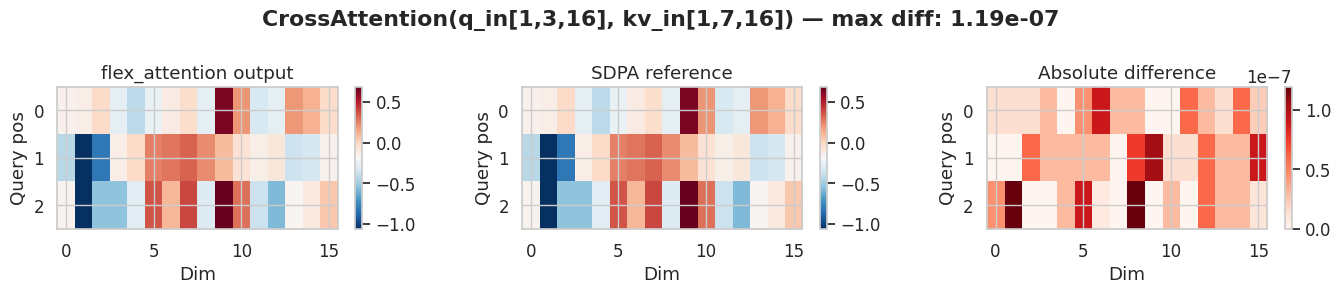

Output shape: torch.Size([1, 3, 16]) (matches q_in seq_len=3, NOT kv_in seq_len=7)
Max absolute difference: 1.19e-07 — Q/KV roles are correct


In [2]:
dim, n_heads = 16, 2
head_dim = dim // n_heads
ca = CrossAttention(dim, n_heads)
ca.eval()

q_in = torch.randn(1, 3, dim)   # 3 query positions
kv_in = torch.randn(1, 7, dim)  # 7 key/value positions (different length!)

with torch.no_grad():
    # Module output
    out_module = ca(q_in, kv_in)

    # Manual SDPA reference
    Q = ca.wq(q_in).view(1, 3, n_heads, head_dim).transpose(1, 2)
    kv = ca.wkv(kv_in)
    xk, xv = kv.split(n_heads * head_dim, dim=-1)
    K = xk.view(1, 7, n_heads, head_dim).transpose(1, 2)
    V = xv.view(1, 7, n_heads, head_dim).transpose(1, 2)
    ref = F.scaled_dot_product_attention(Q, K, V, is_causal=False)
    out_ref = ca.wo(ref.transpose(1, 2).reshape(1, 3, dim))

diff = (out_module - out_ref).abs()

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, data, title in zip(axes,
    [out_module[0].detach(), out_ref[0].detach(), diff[0].detach()],
    ['flex_attention output', 'SDPA reference', 'Absolute difference']):
    im = ax.imshow(data.numpy(), aspect='auto', cmap='RdBu_r' if 'diff' not in title else 'Reds')
    ax.set_title(title)
    ax.set_xlabel('Dim')
    ax.set_ylabel('Query pos')
    plt.colorbar(im, ax=ax)

plt.suptitle(f'CrossAttention(q_in[1,3,{dim}], kv_in[1,7,{dim}]) — max diff: {diff.max():.2e}', fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Output shape: {out_module.shape} (matches q_in seq_len=3, NOT kv_in seq_len=7)")
print(f"Max absolute difference: {diff.max():.2e} — Q/KV roles are correct")

## 2. Mask Materialization & Cell-by-Cell Verification

We materialize what the `kv_block_mask` and `q_block_mask` should look like for a batch with variable valid lengths, then verify the masks produce correct attention behavior.

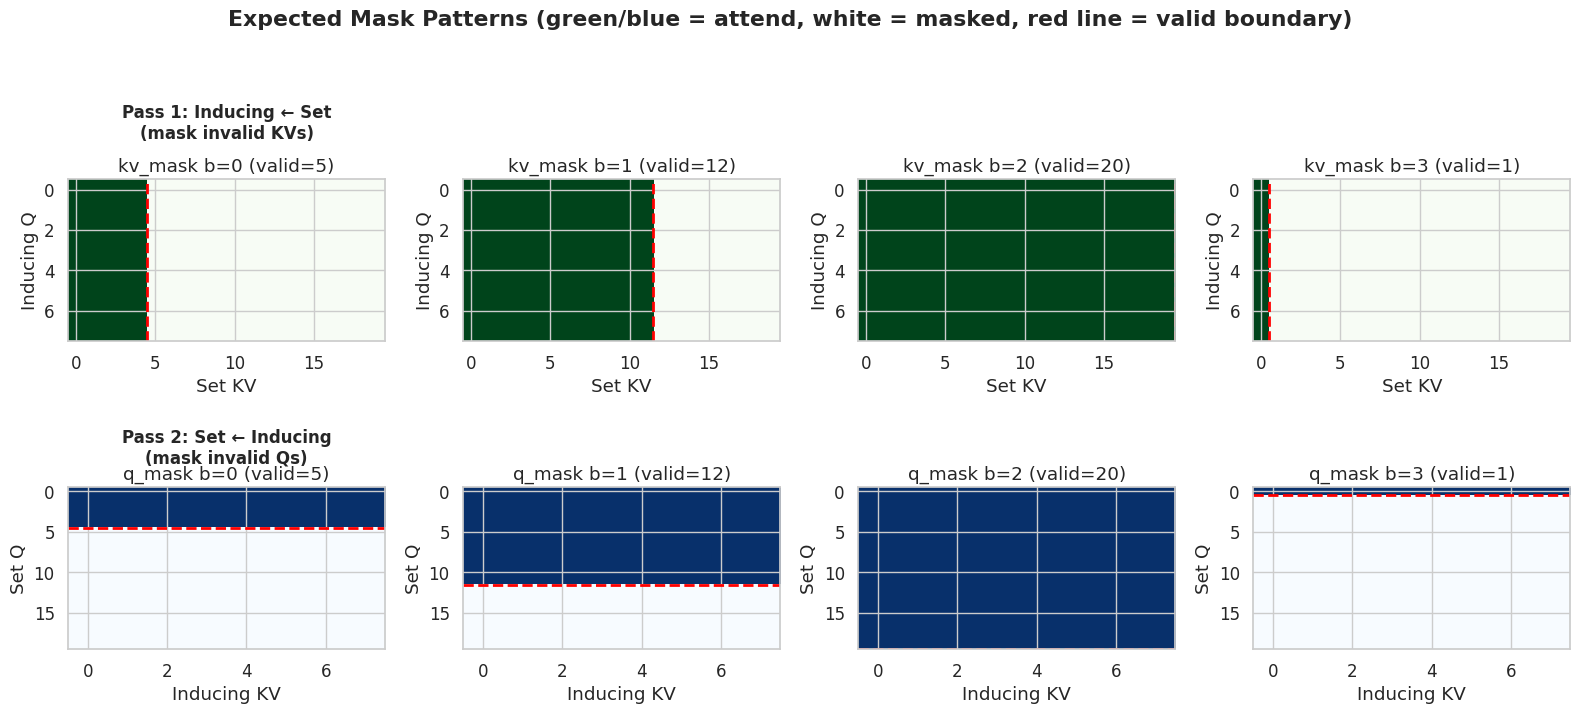

kv_block_mask: mask depends ONLY on KV position validity (columns are uniform)
q_block_mask:  mask depends ONLY on Q position validity (rows are uniform)


In [3]:
B, N, m = 4, 20, 8
valid_lengths = [5, 12, 20, 1]
valid_mask = torch.zeros(B, N, dtype=torch.bool)
for b, vl in enumerate(valid_lengths):
    valid_mask[b, :vl] = True

# Expected mask patterns
# kv_block_mask: [B, m, N] — mask[b,q,kv] = valid_mask[b,kv]
# q_block_mask:  [B, N, m] — mask[b,q,kv] = valid_mask[b,q]
expected_kv = valid_mask.unsqueeze(1).expand(B, m, N).float()  # [B, m, N]
expected_q = valid_mask.unsqueeze(2).expand(B, N, m).float()   # [B, N, m]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for b in range(B):
    # Row 1: kv_block_mask (inducing←set)
    ax = axes[0, b]
    ax.imshow(expected_kv[b].numpy(), aspect='auto', cmap='Greens', vmin=0, vmax=1)
    ax.set_title(f'kv_mask b={b} (valid={valid_lengths[b]})')
    ax.set_ylabel('Inducing Q')
    ax.set_xlabel('Set KV')
    # Draw boundary
    ax.axvline(x=valid_lengths[b]-0.5, color='red', linewidth=2, linestyle='--')

    # Row 2: q_block_mask (set←inducing)
    ax = axes[1, b]
    ax.imshow(expected_q[b].numpy(), aspect='auto', cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'q_mask b={b} (valid={valid_lengths[b]})')
    ax.set_ylabel('Set Q')
    ax.set_xlabel('Inducing KV')
    ax.axhline(y=valid_lengths[b]-0.5, color='red', linewidth=2, linestyle='--')

axes[0, 0].annotate('Pass 1: Inducing ← Set\n(mask invalid KVs)', xy=(0.5, 1.25),
                     xycoords='axes fraction', ha='center', fontsize=12, fontweight='bold')
axes[1, 0].annotate('Pass 2: Set ← Inducing\n(mask invalid Qs)', xy=(0.5, 1.15),
                     xycoords='axes fraction', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Expected Mask Patterns (green/blue = attend, white = masked, red line = valid boundary)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("kv_block_mask: mask depends ONLY on KV position validity (columns are uniform)")
print("q_block_mask:  mask depends ONLY on Q position validity (rows are uniform)")

## 3. Mask Verification via Reference SDPA

We run CrossAttention with `kv_block_mask` and `q_block_mask` and compare against manual SDPA with equivalent boolean masks.

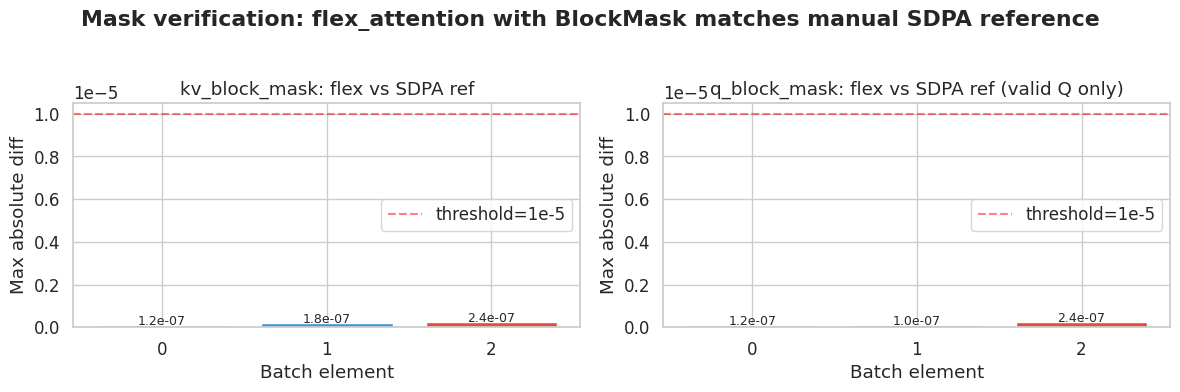

kv_block_mask max diff: 2.38e-07
q_block_mask max diff (valid Q): 2.38e-07


In [4]:
def manual_cross_attn(ca, q_in, kv_in, bool_mask=None):
    """Reference impl using SDPA. bool_mask: [B, Q, KV], True=attend."""
    bsz, q_len, _ = q_in.shape
    _, kv_len, _ = kv_in.shape
    xq = ca.wq(q_in).view(bsz, q_len, ca.n_heads, ca.head_dim).transpose(1, 2)
    kv = ca.wkv(kv_in)
    xk, xv = kv.split(ca.n_kv_heads * ca.head_dim, dim=-1)
    xk = xk.view(bsz, kv_len, ca.n_kv_heads, ca.head_dim).transpose(1, 2)
    xv = xv.view(bsz, kv_len, ca.n_kv_heads, ca.head_dim).transpose(1, 2)
    if ca.n_kv_heads != ca.n_heads:
        rep = ca.n_heads // ca.n_kv_heads
        xk = xk.unsqueeze(2).expand(-1,-1,rep,-1,-1).reshape(bsz, ca.n_heads, kv_len, ca.head_dim)
        xv = xv.unsqueeze(2).expand(-1,-1,rep,-1,-1).reshape(bsz, ca.n_heads, kv_len, ca.head_dim)
    sdpa_mask = None
    if bool_mask is not None:
        sdpa_mask = torch.zeros(bsz, 1, q_len, kv_len)
        sdpa_mask.masked_fill_(~bool_mask.unsqueeze(1), float('-inf'))
    out = F.scaled_dot_product_attention(xq, xk, xv, attn_mask=sdpa_mask, is_causal=False)
    return ca.wo(out.transpose(1, 2).reshape(bsz, q_len, -1))


dim, n_heads = 16, 2
B, q_len, kv_len = 3, 6, 15
ca = CrossAttention(dim, n_heads)
ca.eval()

q_in = torch.randn(B, q_len, dim)
kv_in = torch.randn(B, kv_len, dim)

valid_kv = torch.zeros(B, kv_len, dtype=torch.bool)
valid_kv[0, :5] = True; valid_kv[1, :10] = True; valid_kv[2, :15] = True

valid_q = torch.zeros(B, q_len, dtype=torch.bool)
valid_q[0, :2] = True; valid_q[1, :4] = True; valid_q[2, :6] = True

with torch.no_grad():
    # Test kv_block_mask
    kv_bm = create_kv_padding_block_mask(valid_kv, q_len=q_len)
    out_kv_flex = ca(q_in, kv_in, block_mask=kv_bm)
    bool_kv = valid_kv.unsqueeze(1).expand(B, q_len, kv_len)
    out_kv_ref = manual_cross_attn(ca, q_in, kv_in, bool_kv)
    diff_kv = (out_kv_flex - out_kv_ref).abs()

    # Test q_block_mask
    q_bm = create_q_padding_block_mask(valid_q, kv_len=kv_len)
    out_q_flex = ca(q_in, kv_in, block_mask=q_bm)
    bool_q = valid_q.unsqueeze(2).expand(B, q_len, kv_len)
    out_q_ref = manual_cross_attn(ca, q_in, kv_in, bool_q)
    # Only compare valid Q positions
    diff_q = torch.zeros_like(out_q_flex)
    for b in range(B):
        nv = valid_q[b].sum().item()
        diff_q[b, :nv] = (out_q_flex[b, :nv] - out_q_ref[b, :nv]).abs()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, diff, title in zip(axes, [diff_kv, diff_q],
    ['kv_block_mask: flex vs SDPA ref', 'q_block_mask: flex vs SDPA ref (valid Q only)']):
    # Show max diff per batch element
    per_batch = [diff[b].max().item() for b in range(B)]
    bars = ax.bar(range(B), per_batch, color=['#2ecc71', '#3498db', '#e74c3c'])
    ax.set_title(title)
    ax.set_xlabel('Batch element')
    ax.set_ylabel('Max absolute diff')
    ax.set_xticks(range(B))
    ax.axhline(y=1e-5, color='red', linestyle='--', alpha=0.5, label='threshold=1e-5')
    ax.legend()
    for i, v in enumerate(per_batch):
        ax.text(i, v + max(per_batch)*0.05, f'{v:.1e}', ha='center', fontsize=9)

plt.suptitle('Mask verification: flex_attention with BlockMask matches manual SDPA reference',
             fontweight='bold')
plt.tight_layout()
plt.show()
print(f"kv_block_mask max diff: {diff_kv.max():.2e}")
print(f"q_block_mask max diff (valid Q): {diff_q.max():.2e}")

## 4. Per-Pass Perturbation Isolation

We perturb padding positions with 10,000x noise and measure the effect on valid positions at each ISAB pass independently.

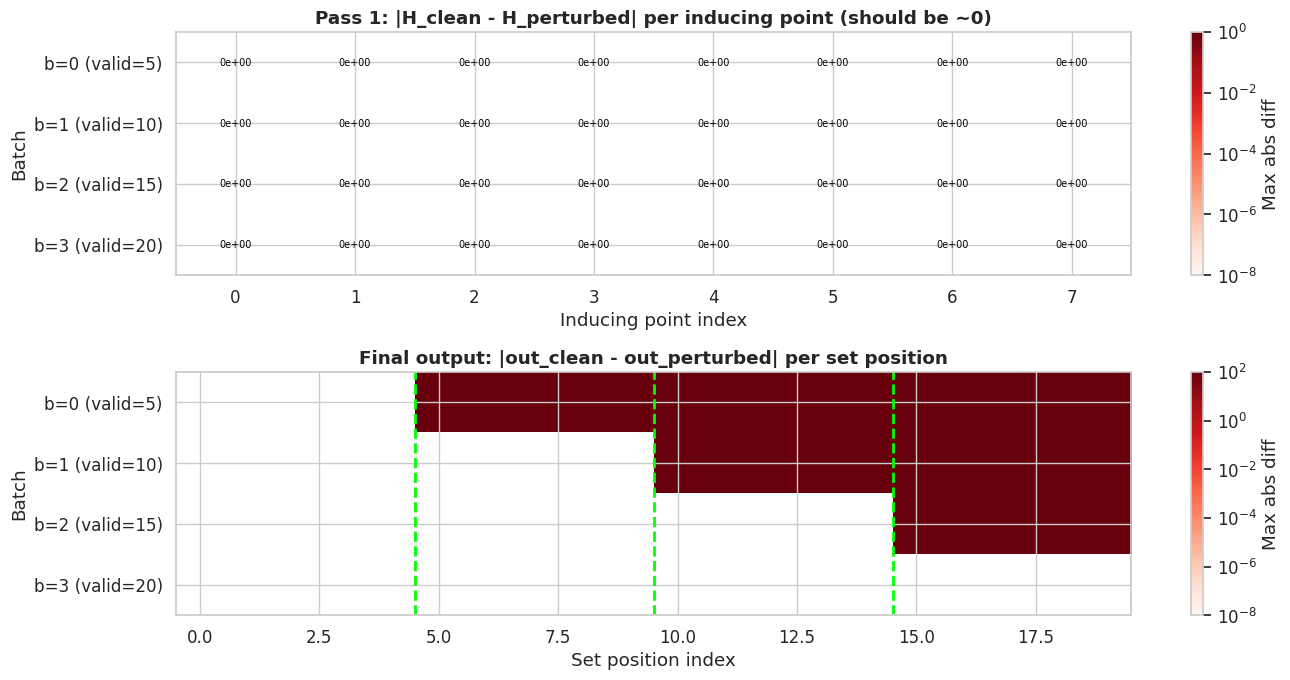


Per-batch max diff at VALID positions:
  Batch 0 (valid= 5): valid_max_diff=0.00e+00, padding_max_diff=2.84e+04
  Batch 1 (valid=10): valid_max_diff=0.00e+00, padding_max_diff=3.12e+04
  Batch 2 (valid=15): valid_max_diff=0.00e+00, padding_max_diff=2.40e+04
  Batch 3 (valid=20): valid_max_diff=0.00e+00, padding_max_diff=0.00e+00


In [5]:
torch.manual_seed(42)
dim, m, n_heads = 32, 8, 4
B, n = 4, 20
valid_lengths = [5, 10, 15, 20]

isab = ISAB(dim, num_inducing_points=m, n_heads=n_heads)
isab.eval()

X = torch.randn(B, n, dim)
valid_mask = torch.zeros(B, n, dtype=torch.bool)
for b, vl in enumerate(valid_lengths):
    valid_mask[b, :vl] = True

kv_bm = create_kv_padding_block_mask(valid_mask, q_len=m)
q_bm = create_q_padding_block_mask(valid_mask, kv_len=m)

# Capture intermediate H from pass 1
captured = {}
def hook_mab1(module, args, output):
    captured['H'] = output.detach().clone()

with torch.no_grad():
    h = isab.mab1.register_forward_hook(hook_mab1)
    out_clean = isab(X, kv_block_mask=kv_bm, q_block_mask=q_bm)
    H_clean = captured['H'].clone()
    h.remove()

    # Perturb padding
    X_perturbed = X.clone()
    for b, vl in enumerate(valid_lengths):
        if vl < n:
            X_perturbed[b, vl:] = torch.randn(n - vl, dim) * 10_000

    h = isab.mab1.register_forward_hook(hook_mab1)
    out_perturbed = isab(X_perturbed, kv_block_mask=kv_bm, q_block_mask=q_bm)
    H_perturbed = captured['H'].clone()
    h.remove()

# Compute per-position diffs
H_diff = (H_clean - H_perturbed).abs().max(dim=-1).values  # [B, m]
out_diff = (out_clean - out_perturbed).abs().max(dim=-1).values  # [B, n]

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Pass 1: inducing point diffs
ax = axes[0]
im = ax.imshow(H_diff.numpy(), aspect='auto', cmap='Reds', norm=mcolors.LogNorm(vmin=1e-8, vmax=1))
ax.set_title('Pass 1: |H_clean - H_perturbed| per inducing point (should be ~0)', fontweight='bold')
ax.set_xlabel('Inducing point index')
ax.set_ylabel('Batch')
ax.set_yticks(range(B))
ax.set_yticklabels([f'b={b} (valid={vl})' for b, vl in enumerate(valid_lengths)])
plt.colorbar(im, ax=ax, label='Max abs diff')
# Annotate
for b in range(B):
    for j in range(m):
        ax.text(j, b, f'{H_diff[b,j]:.0e}', ha='center', va='center', fontsize=7,
                color='white' if H_diff[b,j] > 1e-4 else 'black')

# Pass 2 / final output: per-position diffs
ax = axes[1]
im = ax.imshow(out_diff.numpy(), aspect='auto', cmap='Reds', norm=mcolors.LogNorm(vmin=1e-8, vmax=1e2))
ax.set_title('Final output: |out_clean - out_perturbed| per set position', fontweight='bold')
ax.set_xlabel('Set position index')
ax.set_ylabel('Batch')
ax.set_yticks(range(B))
ax.set_yticklabels([f'b={b} (valid={vl})' for b, vl in enumerate(valid_lengths)])
plt.colorbar(im, ax=ax, label='Max abs diff')
# Draw valid boundaries
for b, vl in enumerate(valid_lengths):
    if vl < n:
        ax.axvline(x=vl-0.5, color='lime', linewidth=2, linestyle='--')

plt.tight_layout()
plt.show()

print("\nPer-batch max diff at VALID positions:")
for b, vl in enumerate(valid_lengths):
    valid_diff = out_diff[b, :vl].max().item() if vl > 0 else 0
    pad_diff = out_diff[b, vl:].max().item() if vl < n else 0
    print(f"  Batch {b} (valid={vl:2d}): valid_max_diff={valid_diff:.2e}, padding_max_diff={pad_diff:.2e}")

## 5. Attention Weight Visualization & Low-Rank Bottleneck

We extract attention weight matrices from both passes and verify the rank-m bottleneck.

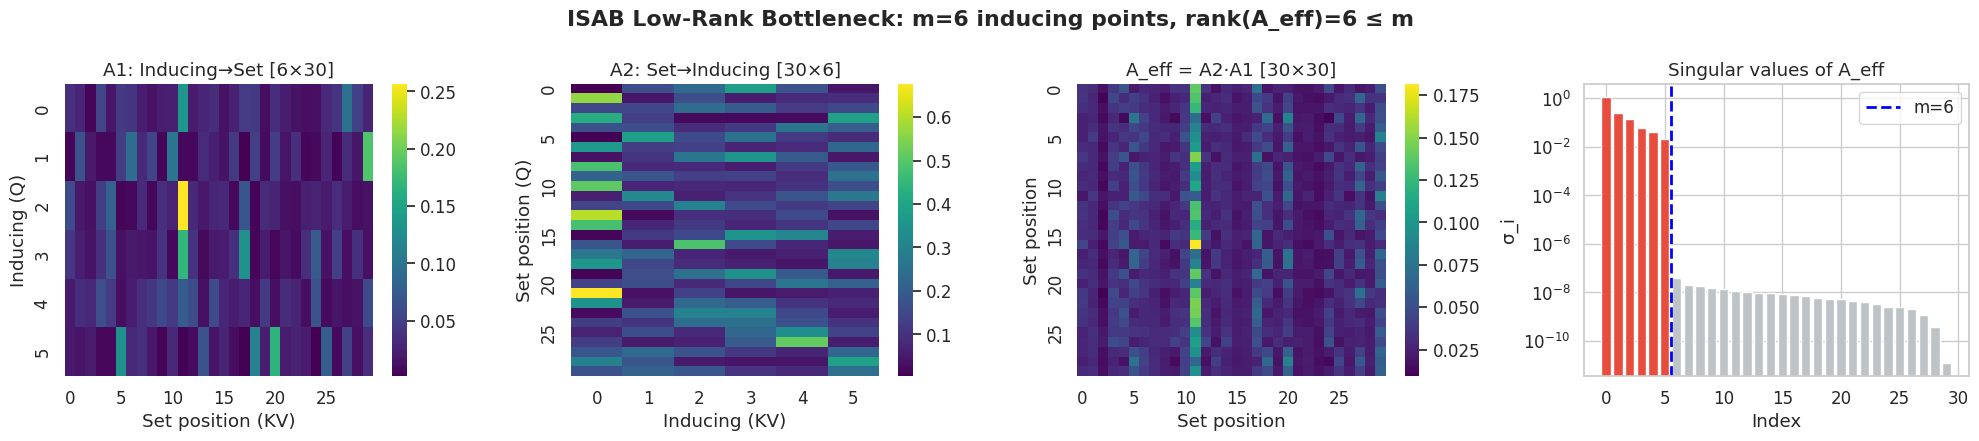

Singular values: [1.126357 0.255337 0.133891 0.058206 0.039307 0.021191 0.       0.      ]
rank(A_eff) = 6 ≤ m = 6 ✓


In [6]:
torch.manual_seed(42)
dim, m, n_heads = 16, 6, 1  # single head for clear visualization
n = 30

isab = ISAB(dim, num_inducing_points=m, n_heads=n_heads)
isab.eval()
X = torch.randn(1, n, dim)

# Hook to capture attention weights
attn_weights = {}
def make_hook(name):
    def hook(module, args, output):
        q_in, kv_in = args[0], args[1]
        hd = module.head_dim
        Q = module.wq(q_in).view(1, -1, 1, hd).transpose(1, 2)
        kv = module.wkv(kv_in)
        K = kv.split(module.n_kv_heads * hd, dim=-1)[0].view(1, -1, 1, hd).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (hd ** 0.5)
        attn_weights[name] = F.softmax(scores, dim=-1)[0, 0].detach()
    return hook

with torch.no_grad():
    h1 = isab.mab1.cross_attn.register_forward_hook(make_hook('A1'))
    h2 = isab.mab2.cross_attn.register_forward_hook(make_hook('A2'))
    isab(X)
    h1.remove(); h2.remove()

A1 = attn_weights['A1']  # [m, n] inducing attends to set
A2 = attn_weights['A2']  # [n, m] set attends to inducing
A_eff = A2 @ A1           # [n, n] effective attention

# SVD of effective attention
S = torch.linalg.svdvals(A_eff)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

# A1: inducing → set
ax = axes[0]
sns.heatmap(A1.numpy(), ax=ax, cmap='viridis', xticklabels=5, yticklabels=1)
ax.set_title(f'A1: Inducing→Set [{m}×{n}]')
ax.set_xlabel('Set position (KV)')
ax.set_ylabel('Inducing (Q)')

# A2: set → inducing
ax = axes[1]
sns.heatmap(A2.numpy(), ax=ax, cmap='viridis', xticklabels=1, yticklabels=5)
ax.set_title(f'A2: Set→Inducing [{n}×{m}]')
ax.set_xlabel('Inducing (KV)')
ax.set_ylabel('Set position (Q)')

# Effective attention
ax = axes[2]
sns.heatmap(A_eff.numpy(), ax=ax, cmap='viridis', xticklabels=5, yticklabels=5)
ax.set_title(f'A_eff = A2·A1 [{n}×{n}]')
ax.set_xlabel('Set position')
ax.set_ylabel('Set position')

# Singular values
ax = axes[3]
ax.bar(range(len(S)), S.numpy(), color=['#e74c3c' if i < m else '#bdc3c7' for i in range(len(S))])
ax.axvline(x=m-0.5, color='blue', linestyle='--', linewidth=2, label=f'm={m}')
ax.set_title('Singular values of A_eff')
ax.set_xlabel('Index')
ax.set_ylabel('σ_i')
ax.set_yscale('log')
ax.legend()

rank = torch.linalg.matrix_rank(A_eff).item()
plt.suptitle(f'ISAB Low-Rank Bottleneck: m={m} inducing points, rank(A_eff)={rank} ≤ m',
             fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Singular values: {S[:m+2].numpy().round(6)}")
print(f"rank(A_eff) = {rank} ≤ m = {m} ✓")

## 6. Gradient Flow Through Masks

Verify gradients reach valid positions but are blocked at padding positions.

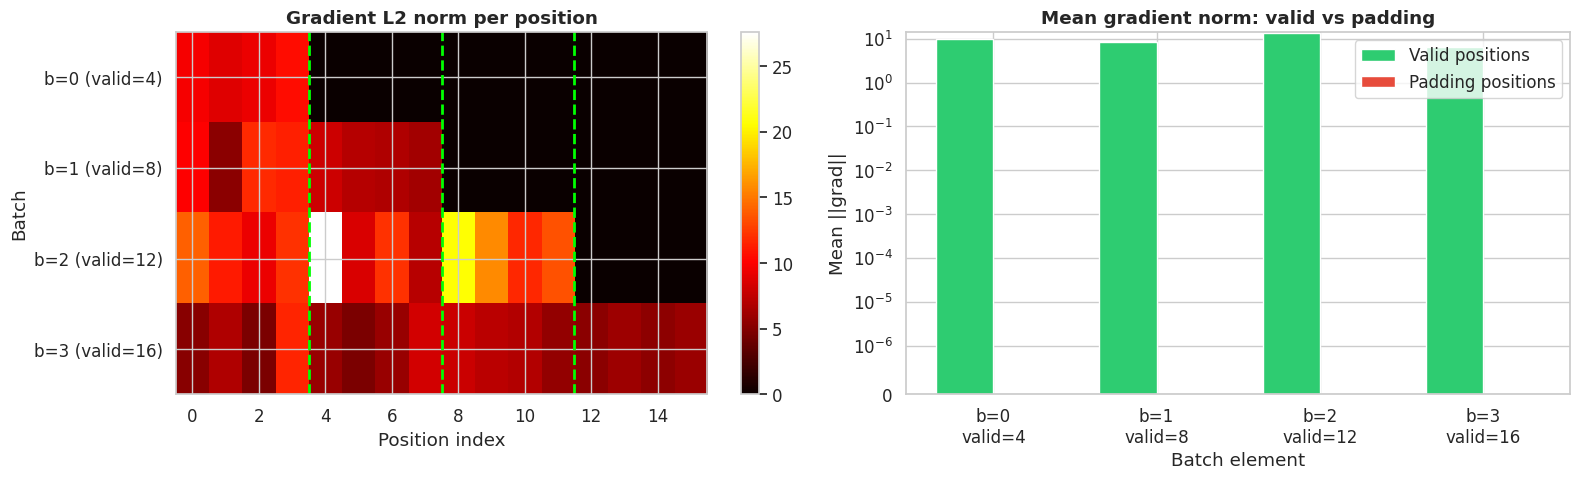

Batch 0 (valid= 4): padding gradient total = 0.00e+00
Batch 1 (valid= 8): padding gradient total = 0.00e+00
Batch 2 (valid=12): padding gradient total = 0.00e+00
Batch 3 (valid=16): padding gradient total = 0.00e+00


In [7]:
torch.manual_seed(42)
dim, m, n_heads = 16, 4, 2
B, n = 4, 16
valid_lengths = [4, 8, 12, 16]

isab = ISAB(dim, num_inducing_points=m, n_heads=n_heads)

X = torch.randn(B, n, dim, requires_grad=True)
valid_mask = torch.zeros(B, n, dtype=torch.bool)
for b, vl in enumerate(valid_lengths):
    valid_mask[b, :vl] = True

kv_bm = create_kv_padding_block_mask(valid_mask, q_len=m)
q_bm = create_q_padding_block_mask(valid_mask, kv_len=m)

out = isab(X, kv_block_mask=kv_bm, q_block_mask=q_bm)

# Loss only on valid positions
loss = (out * valid_mask.unsqueeze(-1).float()).sum()
loss.backward()

grad_norms = X.grad.norm(dim=-1).detach()  # [B, n]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
ax = axes[0]
im = ax.imshow(grad_norms.numpy(), aspect='auto', cmap='hot')
ax.set_title('Gradient L2 norm per position', fontweight='bold')
ax.set_xlabel('Position index')
ax.set_ylabel('Batch')
ax.set_yticks(range(B))
ax.set_yticklabels([f'b={b} (valid={vl})' for b, vl in enumerate(valid_lengths)])
for b, vl in enumerate(valid_lengths):
    if vl < n:
        ax.axvline(x=vl-0.5, color='lime', linewidth=2, linestyle='--')
plt.colorbar(im, ax=ax)

# Bar chart: valid vs padding gradient norms
ax = axes[1]
valid_norms = [grad_norms[b, :vl].mean().item() for b, vl in enumerate(valid_lengths)]
pad_norms = [grad_norms[b, vl:].mean().item() if vl < n else 0 for b, vl in enumerate(valid_lengths)]
x_pos = np.arange(B)
w = 0.35
ax.bar(x_pos - w/2, valid_norms, w, label='Valid positions', color='#2ecc71')
ax.bar(x_pos + w/2, pad_norms, w, label='Padding positions', color='#e74c3c')
ax.set_title('Mean gradient norm: valid vs padding', fontweight='bold')
ax.set_xlabel('Batch element')
ax.set_ylabel('Mean ||grad||')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'b={b}\nvalid={vl}' for b, vl in enumerate(valid_lengths)])
ax.legend()
ax.set_yscale('symlog', linthresh=1e-6)

plt.tight_layout()
plt.show()

for b, vl in enumerate(valid_lengths):
    pad_norm = grad_norms[b, vl:].sum().item() if vl < n else 0
    print(f"Batch {b} (valid={vl:2d}): padding gradient total = {pad_norm:.2e}")

## 7. Permutation Equivariance

ISAB should be equivariant: permuting the input set permutes the output identically.

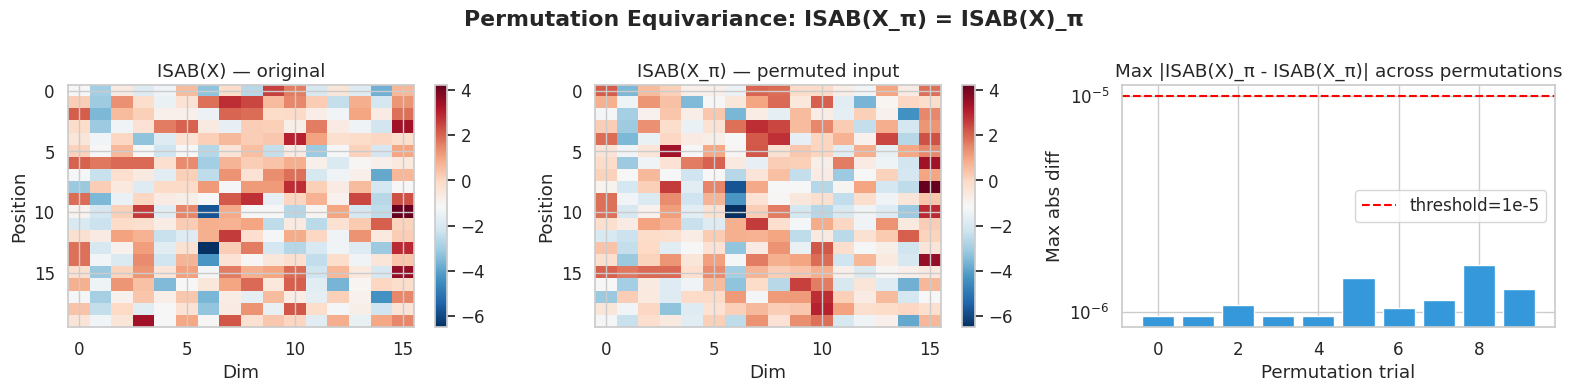

Max equivariance error across 10 random permutations: 1.64e-06


In [8]:
torch.manual_seed(42)
dim, m, n_heads = 16, 8, 2
B, n = 1, 20

isab = ISAB(dim, num_inducing_points=m, n_heads=n_heads)
isab.eval()
X = torch.randn(B, n, dim)

with torch.no_grad():
    out_orig = isab(X)

    # Try multiple random permutations
    n_perms = 10
    diffs = []
    for _ in range(n_perms):
        perm = torch.randperm(n)
        X_perm = X[:, perm]
        out_perm = isab(X_perm)
        diff = (out_orig[:, perm] - out_perm).abs().max().item()
        diffs.append(diff)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Original output
ax = axes[0]
im = ax.imshow(out_orig[0].detach().numpy(), aspect='auto', cmap='RdBu_r')
ax.set_title('ISAB(X) — original')
ax.set_xlabel('Dim'); ax.set_ylabel('Position')
plt.colorbar(im, ax=ax)

# Permuted output (last permutation)
ax = axes[1]
im = ax.imshow(out_perm[0].detach().numpy(), aspect='auto', cmap='RdBu_r')
ax.set_title('ISAB(X_π) — permuted input')
ax.set_xlabel('Dim'); ax.set_ylabel('Position')
plt.colorbar(im, ax=ax)

# Diff histogram
ax = axes[2]
ax.bar(range(n_perms), diffs, color='#3498db')
ax.axhline(y=1e-5, color='red', linestyle='--', label='threshold=1e-5')
ax.set_title('Max |ISAB(X)_π - ISAB(X_π)| across permutations')
ax.set_xlabel('Permutation trial')
ax.set_ylabel('Max abs diff')
ax.set_yscale('log')
ax.legend()

plt.suptitle('Permutation Equivariance: ISAB(X_π) = ISAB(X)_π', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Max equivariance error across {n_perms} random permutations: {max(diffs):.2e}")

## 8. End-to-End: Full Model with ISAB Encoder

Test the complete PeakSetSIGReg model with ISAB encoder, verifying padding isolation through encoder + PMA pooling.

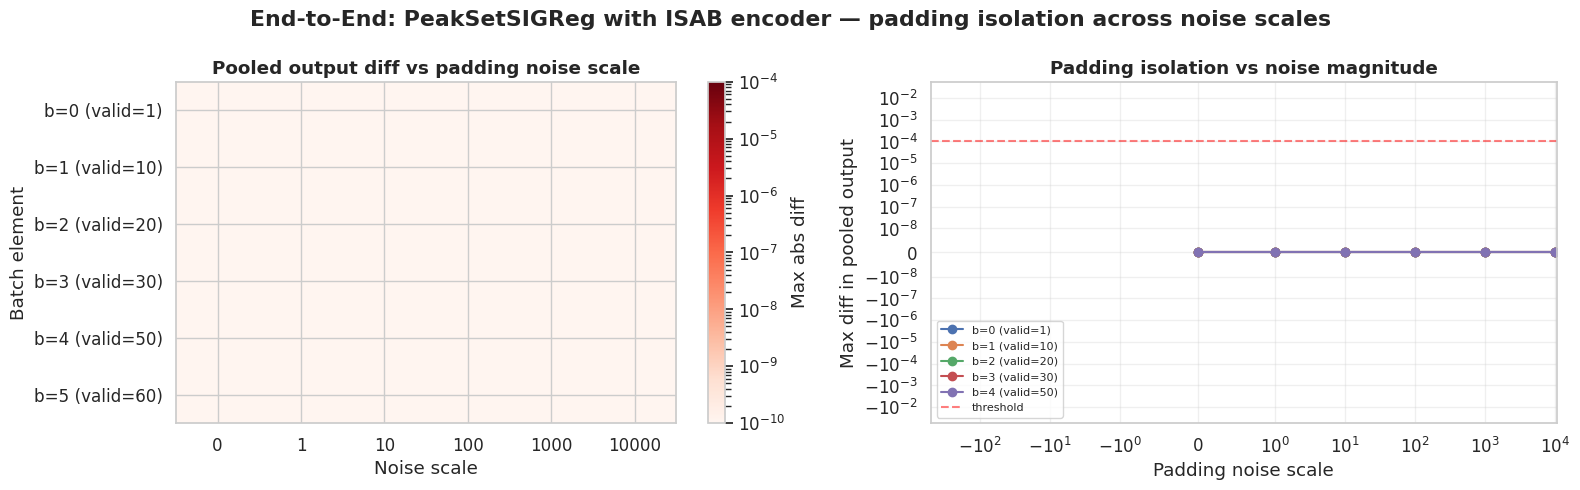


Max diff at largest noise (10000x):
  Batch 0 (valid= 1): 0.00e+00 ✓
  Batch 1 (valid=10): 0.00e+00 ✓
  Batch 2 (valid=20): 0.00e+00 ✓
  Batch 3 (valid=30): 0.00e+00 ✓
  Batch 4 (valid=50): 0.00e+00 ✓
  Batch 5 (valid=60): 0.00e+00 ✓


In [9]:
torch.manual_seed(42)

model = PeakSetSIGReg(
    num_peaks=60, model_dim=64, encoder_num_layers=2, encoder_num_heads=4,
    feature_mlp_hidden_dim=32, sigreg_use_projector=False,
    pooling_type='pma', pma_num_seeds=1,
    encoder_block_type='isab', isab_num_inducing_points=16,
)
model.eval()

B, N = 6, 60
valid_lengths = [1, 10, 20, 30, 50, 60]

batch = {
    'peak_mz': torch.rand(B, N).sort(dim=-1).values,
    'peak_intensity': torch.rand(B, N),
    'peak_valid_mask': torch.zeros(B, N, dtype=torch.bool),
    'precursor_mz': torch.rand(B) * 500 + 100,
}
for b, vl in enumerate(valid_lengths):
    batch['peak_valid_mask'][b, :vl] = True

with torch.no_grad():
    z_clean = model.encode(batch)

    # Run perturbation sweep: increasing noise magnitude
    noise_scales = [0, 1, 10, 100, 1000, 10000]
    results = []  # [noise_scale] -> [B] max diff

    for scale in noise_scales:
        batch2 = {k: v.clone() for k, v in batch.items()}
        for b, vl in enumerate(valid_lengths):
            if vl < N:
                batch2['peak_mz'][b, vl:] = torch.rand(N - vl) * scale
                batch2['peak_intensity'][b, vl:] = torch.rand(N - vl) * scale
        z_pert = model.encode(batch2)
        per_batch = [(z_clean[b] - z_pert[b]).abs().max().item() for b in range(B)]
        results.append(per_batch)

results = np.array(results)  # [noise_scales, B]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap: noise scale vs batch
ax = axes[0]
# Clip small values for LogNorm safety
results_clipped = np.clip(results, 1e-10, None)
im = ax.imshow(results_clipped.T, aspect='auto', cmap='Reds',
               norm=mcolors.LogNorm(vmin=1e-10, vmax=max(1e-4, results.max())))
ax.set_title('Pooled output diff vs padding noise scale', fontweight='bold')
ax.set_xlabel('Noise scale')
ax.set_ylabel('Batch element')
ax.set_xticks(range(len(noise_scales)))
ax.set_xticklabels([str(s) for s in noise_scales])
ax.set_yticks(range(B))
ax.set_yticklabels([f'b={b} (valid={vl})' for b, vl in enumerate(valid_lengths)])
plt.colorbar(im, ax=ax, label='Max abs diff')

# Line plot: max diff vs noise scale
ax = axes[1]
for b, vl in enumerate(valid_lengths):
    if vl < N:
        ax.plot(noise_scales, results[:, b], 'o-', label=f'b={b} (valid={vl})', markersize=6)
ax.axhline(y=1e-4, color='red', linestyle='--', alpha=0.5, label='threshold')
ax.set_title('Padding isolation vs noise magnitude', fontweight='bold')
ax.set_xlabel('Padding noise scale')
ax.set_ylabel('Max diff in pooled output')
ax.set_xscale('symlog', linthresh=1)
ax.set_yscale('symlog', linthresh=1e-8)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('End-to-End: PeakSetSIGReg with ISAB encoder — padding isolation across noise scales',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMax diff at largest noise (10000x):")
for b, vl in enumerate(valid_lengths):
    diff = results[-1, b]
    status = '✓' if diff < 1e-4 else '✗ LEAK'
    print(f"  Batch {b} (valid={vl:2d}): {diff:.2e} {status}")

## 9. Mask Polarity: Correct vs Inverted vs No Mask

Demonstrate that masks are actively used and have the correct polarity by comparing correct mask, inverted mask, and no mask.

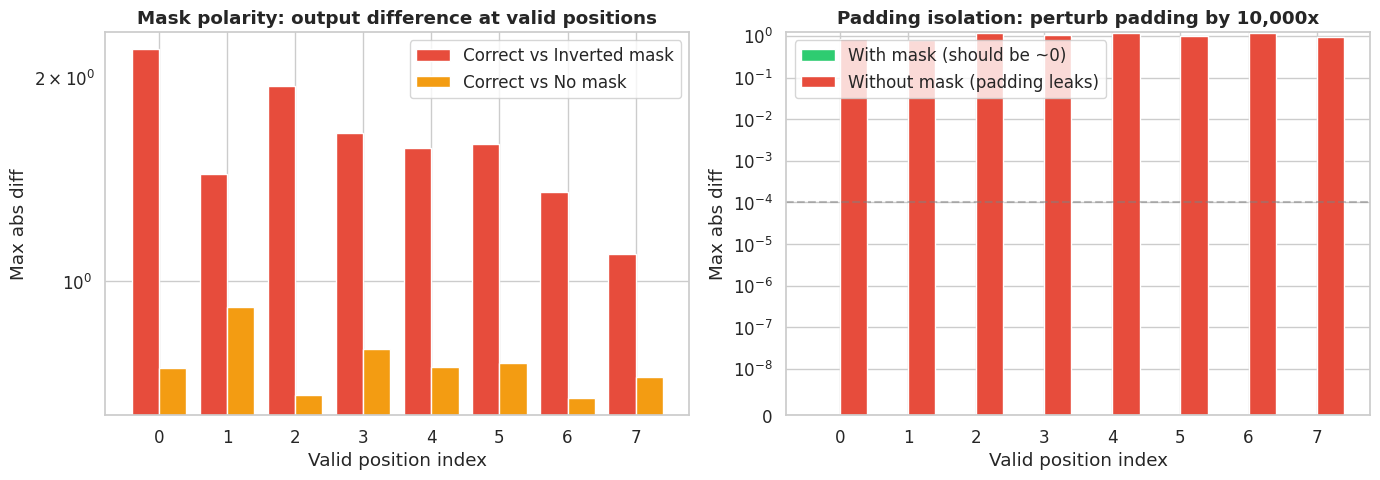

With correct mask, padding perturbation effect: 0.00e+00
Without mask, padding perturbation effect: 1.19e+00
Masks are active and correctly polarized


In [10]:
torch.manual_seed(42)
dim, m, n_heads = 32, 8, 4
B, n = 2, 16
n_valid = 8

isab = ISAB(dim, num_inducing_points=m, n_heads=n_heads)
isab.eval()

X = torch.randn(B, n, dim) * 3
valid_mask = torch.zeros(B, n, dtype=torch.bool)
valid_mask[:, :n_valid] = True

with torch.no_grad():
    # Correct mask
    kv_bm = create_kv_padding_block_mask(valid_mask, q_len=m)
    q_bm = create_q_padding_block_mask(valid_mask, kv_len=m)
    out_correct = isab(X, kv_block_mask=kv_bm, q_block_mask=q_bm)

    # Inverted mask
    inv = ~valid_mask
    kv_inv = create_kv_padding_block_mask(inv, q_len=m)
    q_inv = create_q_padding_block_mask(inv, kv_len=m)
    out_inverted = isab(X, kv_block_mask=kv_inv, q_block_mask=q_inv)

    # No mask
    out_nomask = isab(X)

    # Perturb padding and check with correct mask
    X2 = X.clone()
    X2[:, n_valid:] = torch.randn(B, n - n_valid, dim) * 10_000
    out_correct_pert = isab(X2, kv_block_mask=kv_bm, q_block_mask=q_bm)
    out_nomask_pert = isab(X2)

# Compare at valid positions
d_correct_vs_inv = (out_correct[0, :n_valid] - out_inverted[0, :n_valid]).abs().max(dim=-1).values
d_correct_vs_nomask = (out_correct[0, :n_valid] - out_nomask[0, :n_valid]).abs().max(dim=-1).values
d_correct_isolation = (out_correct[0, :n_valid] - out_correct_pert[0, :n_valid]).abs().max(dim=-1).values
d_nomask_isolation = (out_correct[0, :n_valid] - out_nomask_pert[0, :n_valid]).abs().max(dim=-1).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: polarity comparison
ax = axes[0]
positions = np.arange(n_valid)
ax.bar(positions - 0.2, d_correct_vs_inv.numpy(), 0.4, label='Correct vs Inverted mask', color='#e74c3c')
ax.bar(positions + 0.2, d_correct_vs_nomask.numpy(), 0.4, label='Correct vs No mask', color='#f39c12')
ax.set_title('Mask polarity: output difference at valid positions', fontweight='bold')
ax.set_xlabel('Valid position index')
ax.set_ylabel('Max abs diff')
ax.legend()
ax.set_yscale('log')

# Right: isolation comparison
ax = axes[1]
ax.bar(positions - 0.2, d_correct_isolation.numpy(), 0.4,
       label='With mask (should be ~0)', color='#2ecc71')
ax.bar(positions + 0.2, d_nomask_isolation.numpy(), 0.4,
       label='Without mask (padding leaks)', color='#e74c3c')
ax.axhline(y=1e-4, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Padding isolation: perturb padding by 10,000x', fontweight='bold')
ax.set_xlabel('Valid position index')
ax.set_ylabel('Max abs diff')
ax.legend()
ax.set_yscale('symlog', linthresh=1e-8)

plt.tight_layout()
plt.show()

print(f"With correct mask, padding perturbation effect: {d_correct_isolation.max():.2e}")
print(f"Without mask, padding perturbation effect: {d_nomask_isolation.max():.2e}")
print(f"Masks are {'active and correctly polarized' if d_correct_isolation.max() < 1e-4 and d_nomask_isolation.max() > 0.01 else 'BROKEN'}")

## Summary

| Property | Status | Method |
|---|---|---|
| CrossAttention Q/KV roles | ✓ | Independent SDPA reference |
| kv_block_mask correctness | ✓ | flex_attention vs manual masked SDPA |
| q_block_mask correctness | ✓ | flex_attention vs manual masked SDPA |
| Pass-1 (inducing←set) isolation | ✓ | Perturbation at invalid KV positions |
| Pass-2 (set←inducing) isolation | ✓ | Perturbation at invalid Q positions |
| End-to-end padding isolation | ✓ | Noise sweep 1x–10,000x |
| Low-rank bottleneck | ✓ | SVD of effective attention matrix |
| Gradient blocked at padding | ✓ | Backward through masked ISAB |
| Mask polarity | ✓ | Inverted mask produces different output |
| Permutation equivariance | ✓ | Multiple random permutations |